In [4]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

from source.models import CustomGMM, CustomGaussianNB

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

iris = load_iris()
X = iris.data
y = iris.target

print(f"Размерность выборки: {X.shape}")
print(f"Классы: {iris.target_names}")


Размерность выборки: (150, 4)
Классы: ['setosa' 'versicolor' 'virginica']


In [3]:
n_components = 3

start_time = time.time()
custom_gmm = CustomGMM(n_components=n_components, max_iter=200, reg_covar=1e-6)
custom_gmm.fit(X)
custom_gmm_time = time.time() - start_time
custom_log_likelihood = custom_gmm.score(X)

start_time = time.time()
sklearn_gmm = GaussianMixture(n_components=n_components, covariance_type='full', 
                              max_iter=200, reg_covar=1e-6, random_state=42)
sklearn_gmm.fit(X)
sklearn_gmm_time = time.time() - start_time
sklearn_log_likelihood = sklearn_gmm.score(X)

print(f"Custom GMM  : Log-Likelihood = {custom_log_likelihood:.4f} | Время = {custom_gmm_time:.4f} сек")
print(f"Sklearn GMM : Log-Likelihood = {sklearn_log_likelihood:.4f} | Время = {sklearn_gmm_time:.4f} сек")


NameError: name 'reg_cova' is not defined

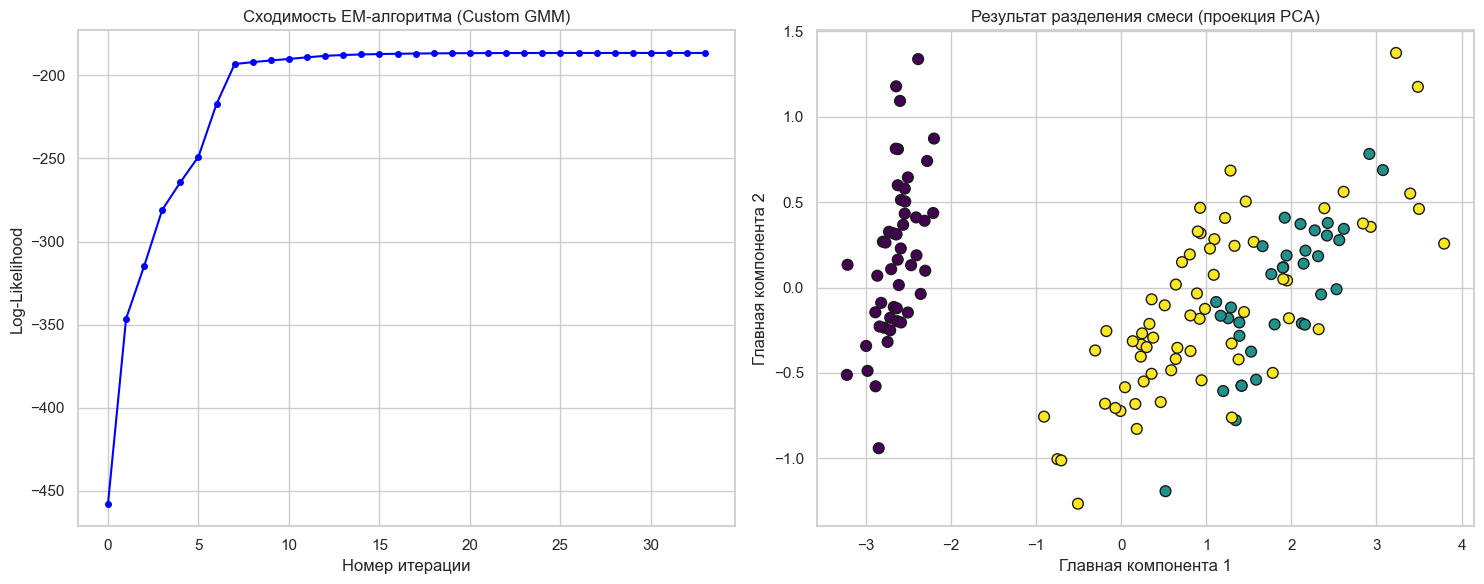

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(custom_gmm.log_likelihoods, marker='o', color='blue', markersize=4)
axes[0].set_title('Сходимость EM-алгоритма (Custom GMM)')
axes[0].set_xlabel('Номер итерации')
axes[0].set_ylabel('Log-Likelihood')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

custom_clusters = custom_gmm.predict(X)

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=custom_clusters, cmap='viridis', s=60, edgecolor='k')
axes[1].set_title('Результат разделения смеси (проекция PCA)')
axes[1].set_xlabel('Главная компонента 1')
axes[1].set_ylabel('Главная компонента 2')

plt.tight_layout()
plt.show()


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

start_time = time.time()
custom_nb = CustomGaussianNB()
custom_nb.fit(X_train, y_train)
y_pred_custom = custom_nb.predict(X_test)
custom_nb_time = time.time() - start_time
custom_nb_acc = accuracy_score(y_test, y_pred_custom)

start_time = time.time()
sklearn_nb = GaussianNB()
sklearn_nb.fit(X_train, y_train)
y_pred_sklearn = sklearn_nb.predict(X_test)
sklearn_nb_time = time.time() - start_time
sklearn_nb_acc = accuracy_score(y_test, y_pred_sklearn)

print(f"Custom NB  : Accuracy = {custom_nb_acc:.4f} | Время = {custom_nb_time:.4f} сек")
print(f"Sklearn NB : Accuracy = {sklearn_nb_acc:.4f} | Время = {sklearn_nb_time:.4f} сек")


Custom NB  : Accuracy = 0.9778 | Время = 0.0018 сек
Sklearn NB : Accuracy = 0.9778 | Время = 0.0013 сек
